Confusion Matrix:
 [[249   6]
 [ 37   2]]


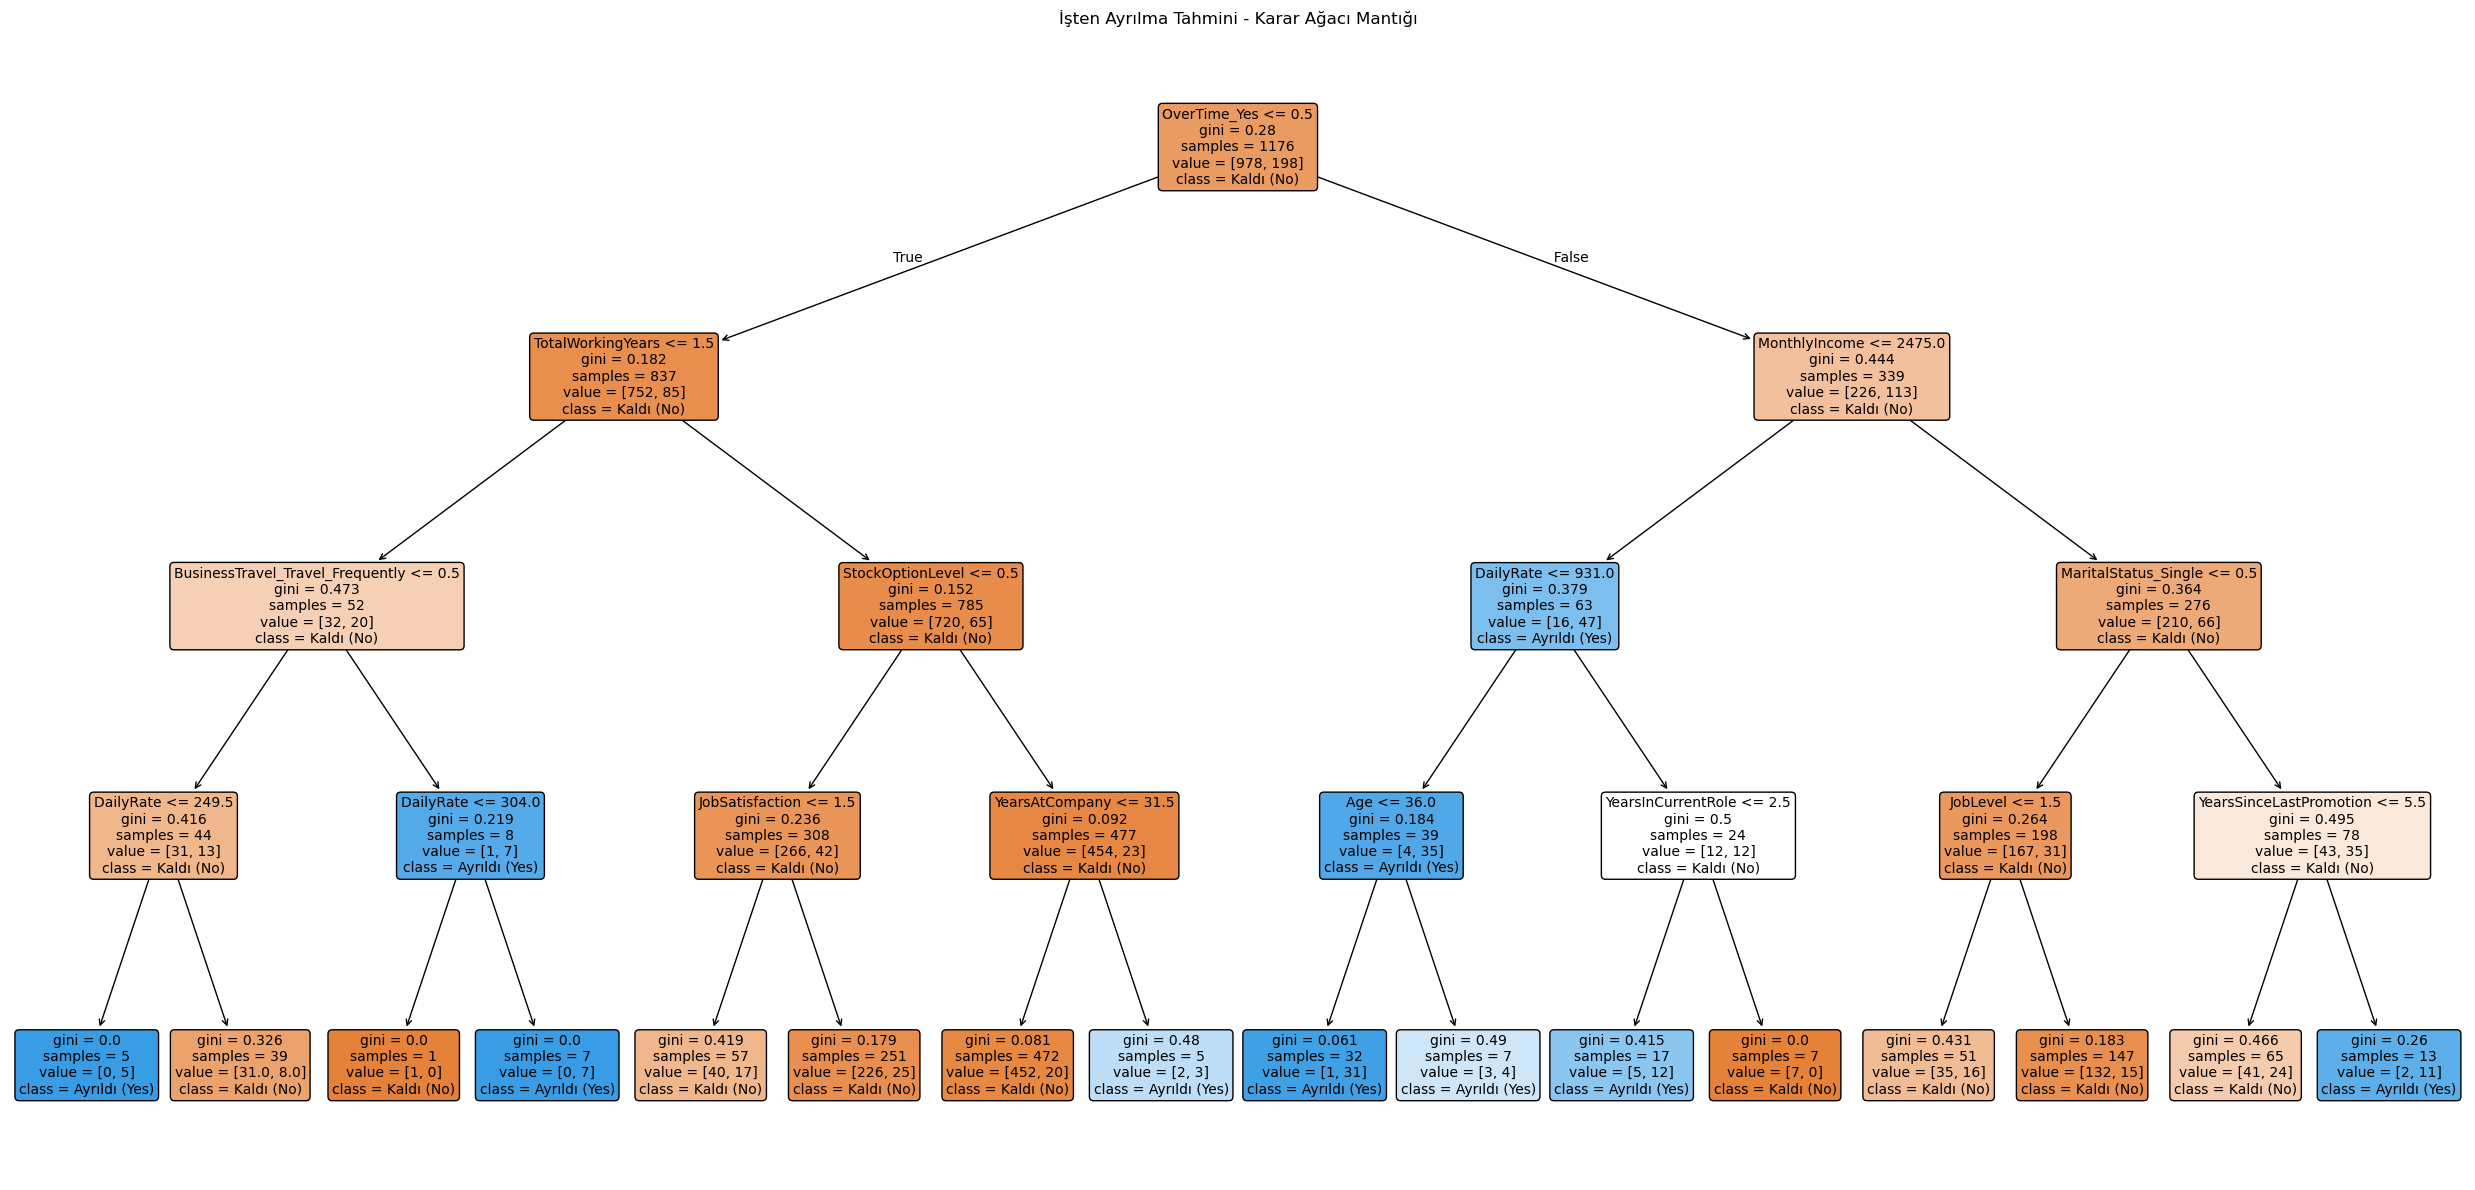

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. VERİYİ OKUMA
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. BAĞIMSIZ (X) VE BAĞIMLI (y) DEĞİŞKENLERİ AYIRMA
# Hedef değişkenimiz 'Attrition' (İşten ayrılma durumu: Yes/No)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 3. PREPROCESSING & ENCODING (Kategorik verileri sayılara çevirme)
# Veri setindeki metin olan tüm sütunları tespit edip Dummy Variable Trap'ten kaçınarak 1 ve 0'lara çeviriyoruz.
categoric_column = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus','OverTime','Over18']
X_encoded = pd.get_dummies(X, columns=categoric_column, drop_first=True)

# 4. TRAIN - TEST SPLIT (Veriyi %80 Eğitim, %20 Test olarak ayırma)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

# 5. DECISION TREE KURULUMU
# max_depth=4 vererek ağacın gereksiz detaylarda boğulup ezber yapmasını (Overfitting) engelliyoruz
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# 6. PREDICTION VE RAPORLAMA
y_pred = tree_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 7. AĞACI GÖRSELLEŞTİRME 
plt.figure(figsize=(25, 12)) # Ağaç büyük olduğu için figür boyutunu geniş tuttuk
plot_tree(tree_model, 
          feature_names=X_encoded.columns, 
          class_names=['Kaldı (No)', 'Ayrıldı (Yes)'], # Hedef sınıflarımız
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("İşten Ayrılma Tahmini - Karar Ağacı Mantığı")
plt.tight_layout()
plt.show()

Tek bir Karar Ağacı (Decision Tree) çok zekidir ancak son derece kırılgandır. Veri setindeki tek bir kişiyi bile değiştirseniz, ağaç en tepedeki soruyu değiştirip bambaşka bir yapı çizebilir (Buna Yüksek Varyans denir). Random Forest ise bu kırılganlığı üç muazzam mühendislik taktiği ile ortadan kaldırarak beton gibi stabil bir model yaratır:

1. Bagging (Rastgele Veri Dağıtımı)
Random Forest arka planda 100 ağaç kurduğunda, tüm ağaçlara aynı veriyi vermez. Veri setinin içinden rastgele ve farklı kısımları seçerek (Bootstrap) her ağaca farklı bir "eğitim seti" sunar. Böylece kimi ağaçlar genç çalışanları daha çok incelerken, kimi ağaçlar tecrübeli çalışanları daha çok inceler. Hiçbir ağaç verinin tamamını ezberleyemez (Overfitting engellenir).

2. Feature Randomness (Rastgele Özellik Seçimi)
Ağaçlar sadece satırları (çalışanları) değil, sütunları da (özellikleri) rastgele seçer. Örneğin, ormandaki bir ağaç sadece Maaş ve Fazla Mesai verilerine bakarak karar vermeye çalışırken, bir diğeri sadece Yaş ve Memnuniyet Skoruna bakar. Bu sayede modelin tamamı tek bir güçlü özelliğe körü körüne bağımlı olmaktan kurtulur ve verinin her detayını öğrenme fırsatı bulur.

In [9]:
# RANDOM FOREST KURULUMU
# n_estimators=100: Arka planda 100 tane karar ağacı kurar.
# class_weight='balanced': Dengesiz veriler için HARİKA bir ayardır. Ayrılanları (azınlığı) yakalamak için modele ekstra ceza puanları verir.
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[248   7]
 [ 31   8]]
